#Step 1: Import Libraries

In [1]:
# Step 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Optional: To ignore warnings
import warnings
warnings.filterwarnings('ignore')

#Step 2: Load Your Dataset 

In [4]:
# Step 2: Load your dataset
df = pd.read_csv("C:/Users/AHMAD KHAN/Downloads/heart_disease_dataset (1).csv")  # Replace with your CSV file name
df.head()  # Display first 5 rows to check

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


Step 3: Check Dataset Info

In [5]:
# Step 3: Check for missing values and data types
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

Step 4: Encode Categorical Variables

In [6]:
# Step 4: Encode categorical variables
le = LabelEncoder()
categorical_cols = ['Gender', 'Smoking', 'Alcohol Intake', 'Chest Pain Type', 'Exercise Induced Angina', 
                    'Family History', 'Diabetes', 'Obesity']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()  # Check the changes

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,0,228,119,66,0,0,1,0,0,1,8,119,1,1,1
1,48,1,204,165,62,0,2,5,0,0,0,9,70,1,3,0
2,53,1,234,91,67,2,0,3,1,0,1,5,196,1,1,1
3,69,0,192,90,72,0,2,4,0,1,0,7,107,1,2,0
4,62,0,172,163,93,2,2,6,0,1,0,2,183,1,0,0


Step 5: Split Features and Target

In [7]:
# Step 5: Separate features and target
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 15)
Target shape: (1000,)


Step 6: Train/Test Split

In [8]:
# Step 6: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (800, 15)
X_test shape: (200, 15)


Step 7: Train Random Forest Model

In [9]:
# Step 7: Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 7b: Make predictions
y_pred = model.predict(X_test)

# Step 7c: Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[118   0]
 [  0  82]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00        82

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Step 8: Feature Importance Visualization

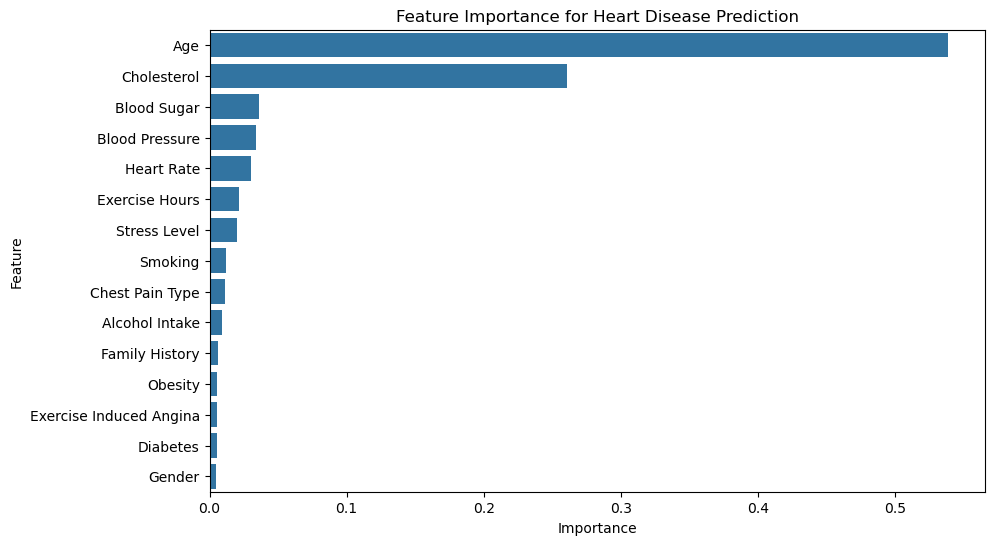

In [10]:
# Step 8: Check which features are most important
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance for Heart Disease Prediction")
plt.show()

Step 9 : Compare Multiple Models

In [11]:
# Step 9: Compare Logistic Regression, Random Forest, and SVM
models = [LogisticRegression(max_iter=500), RandomForestClassifier(n_estimators=100), SVC()]
for m in models:
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    print(m.__class__.__name__, "Accuracy:", accuracy_score(y_test, y_pred))

LogisticRegression Accuracy: 0.86
RandomForestClassifier Accuracy: 1.0
SVC Accuracy: 0.93


Step 10: Confusion Matrix Visualization

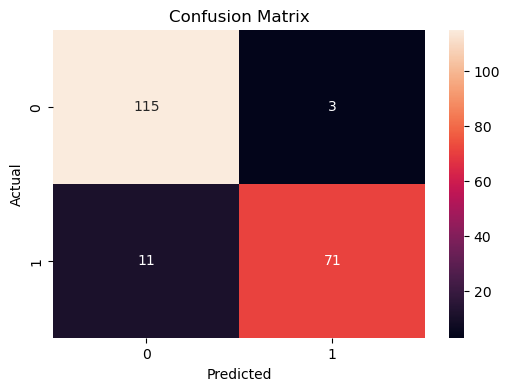

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()